# Adult Income Dataset - Exploratory Data Analysis

Goal:
- Understand dataset structure
- Detect missing values
- Explore feature distributions
- Identify relationships with target variable
- Prepare insights for Decision Tree modeling

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  
import warnings
warnings.filterwarnings("ignore")


#### Load Dataset

In [6]:
columns = [
'age','workclass','fnlwgt','education','education_num','marital_status',
'occupation','relationship','race','sex','capital_gain','capital_loss',
'hours_per_week','native_country','income'
]

df = pd.read_csv("../data/raw/adult.data", names=columns)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [9]:
df.shape

(32561, 15)

In [10]:
(df == "?").sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [11]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


#### Target veriable destribution

In [12]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

#### Numerical feature

In [13]:
numerical_features = df.select_dtypes(include=['int64']).columns

numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='str')

#### Age Distribution

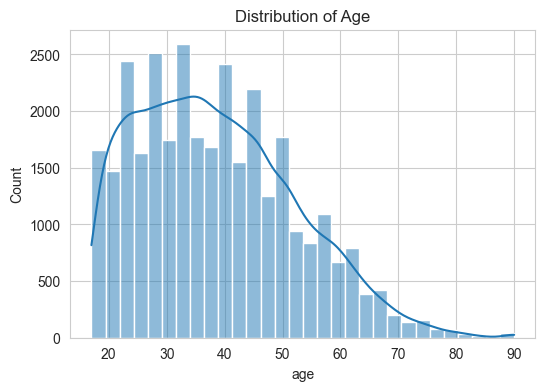

In [16]:
plt.figure(figsize=(6,4) )
sns.histplot(df["age"], bins = 30, kde=True)
plt.title("Distribution of Age")
plt.show()


#### Hours per week distribution

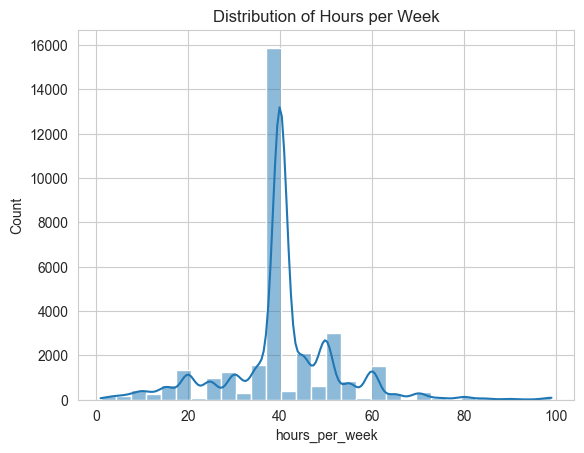

In [17]:
plt.Figure(figsize=(6,4))
sns.histplot(df["hours_per_week"], bins = 30, kde=True)
plt.title("Distribution of Hours per Week")

plt.show()


#### Capital Gain distribution

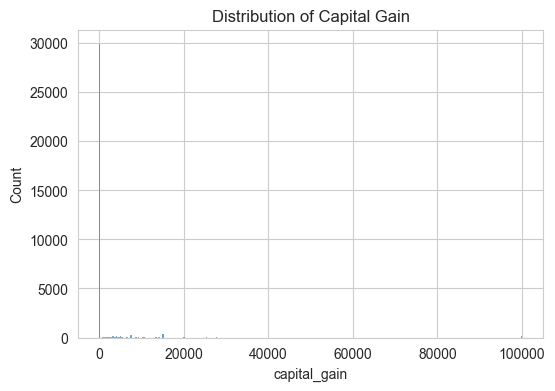

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["capital_gain"])
plt.title("Distribution of Capital Gain")
plt.show()

Highly skewed distribution

#### Categorical Columns

In [20]:
categorical_features = df.select_dtypes(include=['object']).columns

categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='str')

#### Workclass Distribution

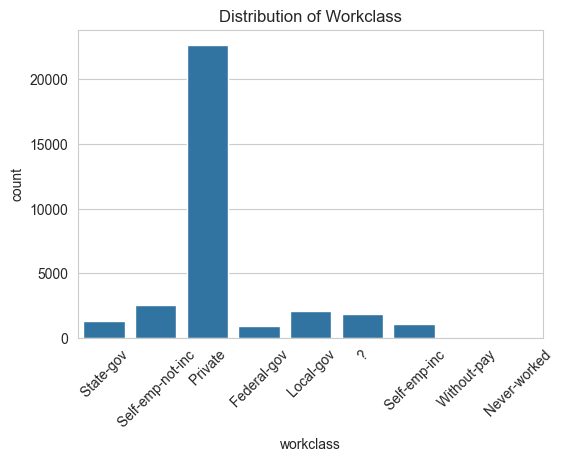

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='workclass')

plt.xticks(rotation=45)

plt.title("Distribution of Workclass")
plt.show()

#### Education Distribution

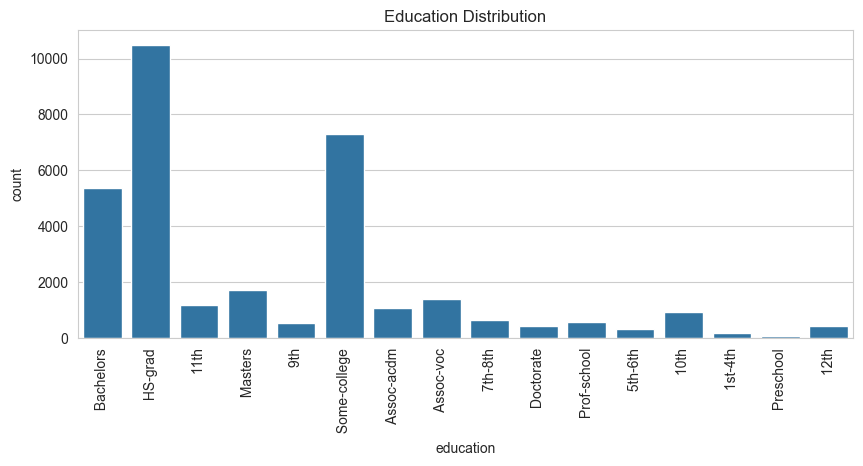

In [23]:
plt.figure(figsize=(10,4))

sns.countplot(data=df, x='education')

plt.xticks(rotation=90)

plt.title("Education Distribution")

plt.show()

#### Gender vs Income

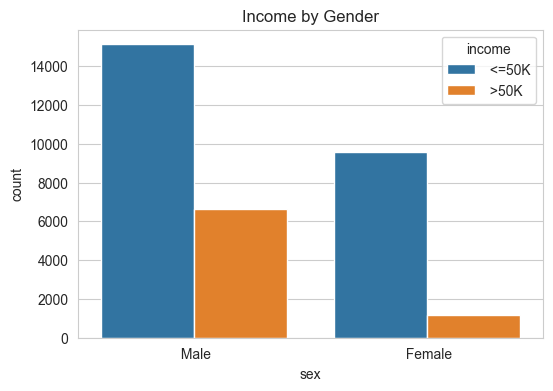

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sex', hue='income')

plt.title("Income by Gender")

plt.show()

#### Education vs income

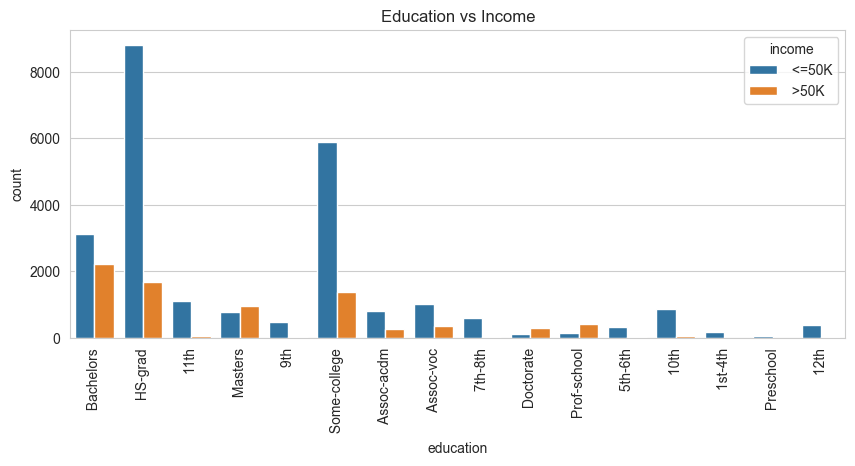

In [25]:
plt.figure(figsize=(10,4))

sns.countplot(data=df, x='education', hue='income')

plt.xticks(rotation=90)

plt.title("Education vs Income")

plt.show()

#### Age vs income

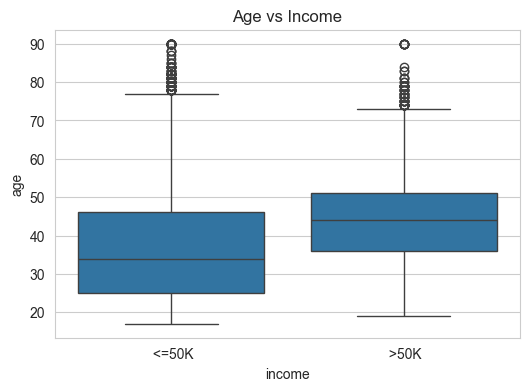

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='income', y='age')

plt.title("Age vs Income")

plt.show()

#### Corelation Matric

In [33]:
df_encoded = df.copy()

# Clean text columns first, then convert to numeric codes for correlation
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype(str).str.strip()
    df_encoded[col] = df_encoded[col].replace('?', np.nan)
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

#### Corelation heatmap

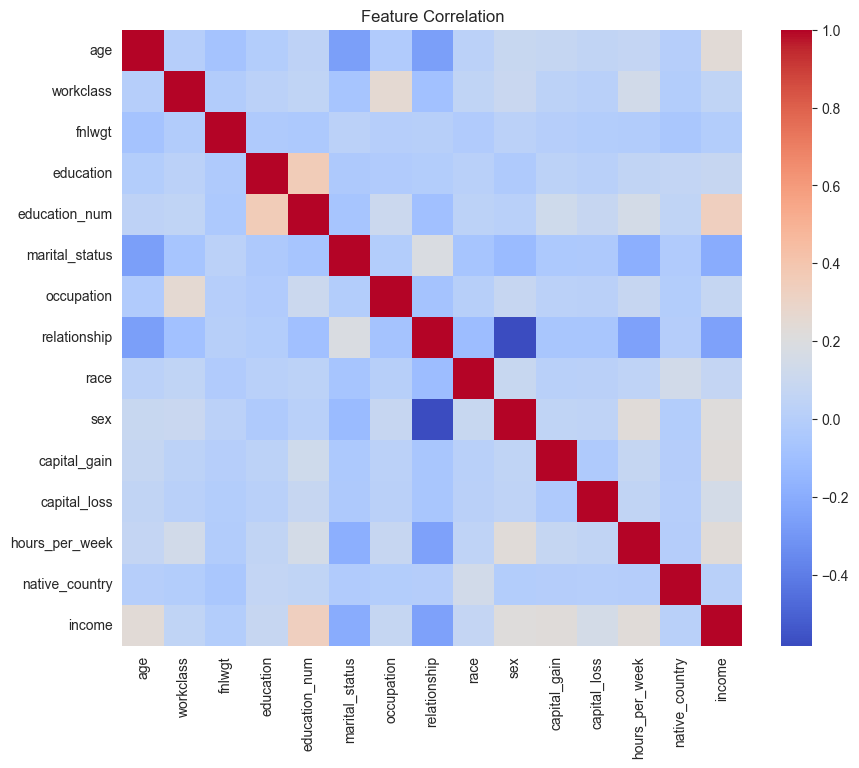

In [32]:
plt.figure(figsize=(10,8))

corr_matrix = df_encoded.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title('Feature Correlation')

plt.show()

## Key Insights

1. Dataset contains both categorical and numerical features.
2. Missing values exist as "?" in some columns.
3. Dataset is slightly imbalanced (>50K minority).
4. Education level strongly influences income.
5. Age and working hours impact salary prediction.
6. Capital gain and capital loss have highly skewed distributions.

These insights will guide feature preprocessing for Decision Tree modeling.